In [30]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sahilislam007/global-environment-and-air-pollution-dataset/global_environment_air_pollution_dataset.csv


In [31]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px
plt.rcParams["figure.figsize"] = (12,6)

In [32]:
df=pd.read_csv(r"/kaggle/input/datasets/sahilislam007/global-environment-and-air-pollution-dataset/global_environment_air_pollution_dataset.csv")

# Data Info

In [33]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())

Shape: (300000, 14)

Columns:
 Index(['country', 'city', 'region', 'year', 'month', 'temperature_c',
       'humidity_percent', 'pm2_5', 'pm10', 'no2', 'so2', 'co', 'aqi',
       'green_cover_percent'],
      dtype='object')

Data Types:
 country                 object
city                    object
region                  object
year                     int64
month                    int64
temperature_c          float64
humidity_percent         int64
pm2_5                  float64
pm10                   float64
no2                    float64
so2                    float64
co                     float64
aqi                      int64
green_cover_percent    float64
dtype: object

Missing Values:
 country                0
city                   0
region                 0
year                   0
month                  0
temperature_c          0
humidity_percent       0
pm2_5                  0
pm10                   0
no2                    0
so2                    0
co                  

# Data Handling & Cleaning

In [34]:
df.isna().sum()
df.duplicated().sum()

np.int64(0)

# EDA & Visualization

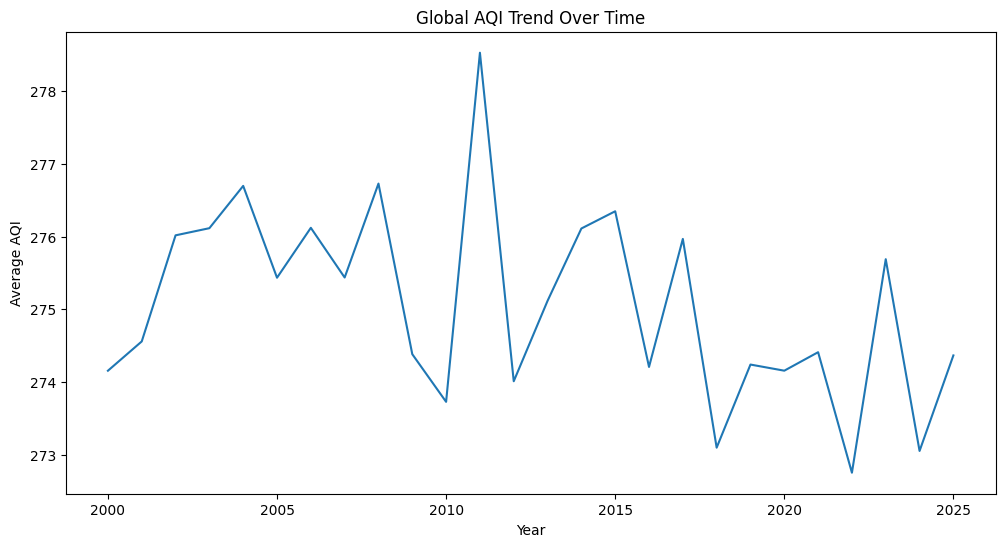

In [35]:
# 5. Global AQI Trend Over Time
aqi_trend = df.groupby("year")["aqi"].mean()

plt.figure(figsize=(12,6))
plt.plot(aqi_trend.index, aqi_trend.values)
plt.title("Global AQI Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.show()


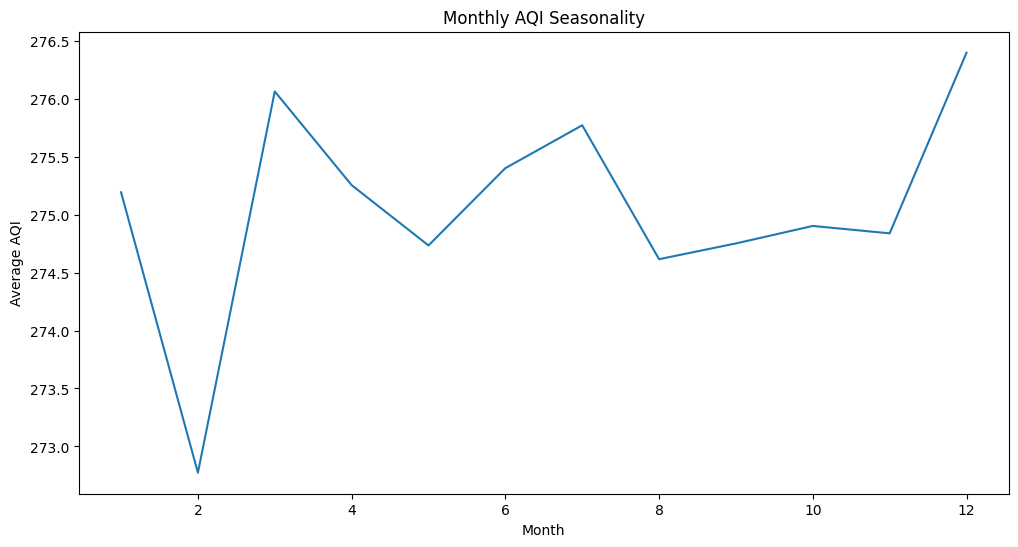

In [36]:
# 6. Monthly Seasonality Analysis
monthly_aqi = df.groupby("month")["aqi"].mean()

plt.figure(figsize=(12,6))
plt.plot(monthly_aqi.index, monthly_aqi.values)
plt.title("Monthly AQI Seasonality")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()

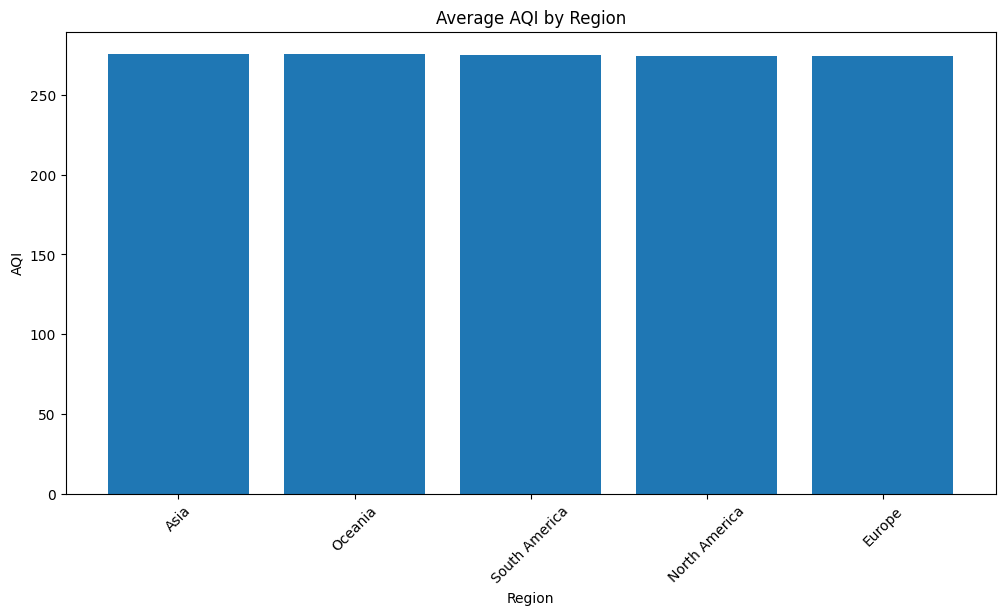

In [37]:
# 7. Regional AQI Comparison
region_aqi = df.groupby("region")["aqi"].mean().sort_values(ascending=False)

plt.figure()
plt.bar(region_aqi.index, region_aqi.values)
plt.xticks(rotation=45)
plt.title("Average AQI by Region")
plt.xlabel("Region")
plt.ylabel("AQI")
plt.show()

In [38]:
# 8. Top 10 Most Polluted Cities
city_pollution = df.groupby("city")["aqi"].mean().sort_values(ascending=False).head(10)
print("\nTop 10 Polluted Cities:\n", city_pollution)


Top 10 Polluted Cities:
 city
CityB    276.232147
CityA    275.857870
CityC    275.668108
CityI    275.347899
CityE    274.893756
CityJ    274.854828
CityD    274.699977
CityF    274.430925
CityH    274.328492
CityG    274.251595
Name: aqi, dtype: float64



Top 10 Cleanest Cities:
 city
CityG    274.251595
CityH    274.328492
CityF    274.430925
CityD    274.699977
CityJ    274.854828
CityE    274.893756
CityI    275.347899
CityC    275.668108
CityA    275.857870
CityB    276.232147
Name: aqi, dtype: float64


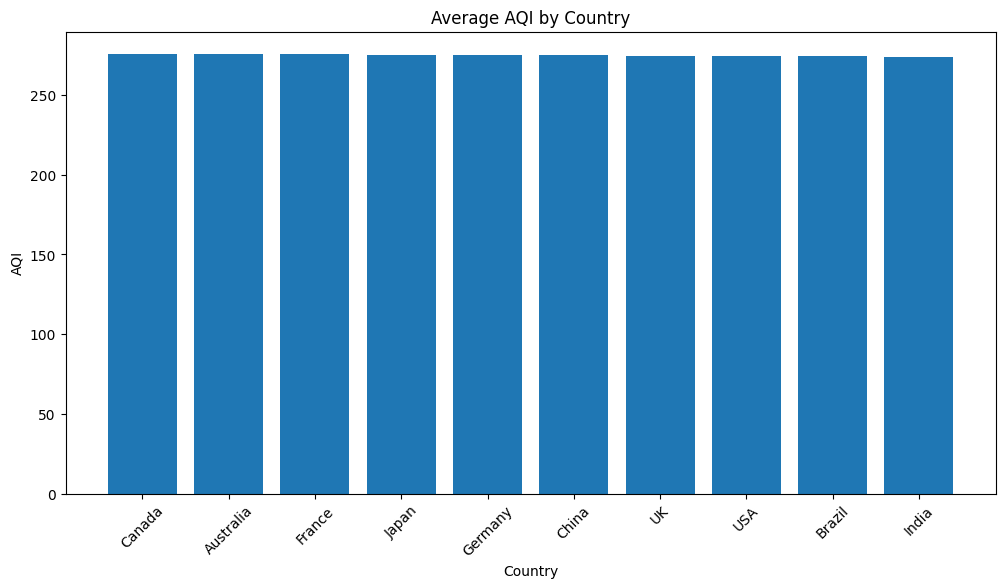

In [39]:
# 9. Top 10 Cleanest Cities
clean_cities = df.groupby("city")["aqi"].mean().sort_values().head(10)
print("\nTop 10 Cleanest Cities:\n", clean_cities)

# 10. Country-wise AQI Comparison
country_aqi = df.groupby("country")["aqi"].mean().sort_values(ascending=False)

plt.figure()
plt.bar(country_aqi.index, country_aqi.values)
plt.xticks(rotation=45)
plt.title("Average AQI by Country")
plt.xlabel("Country")
plt.ylabel("AQI")
plt.show()

In [40]:
# 11. Correlation Analysis
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
print("\nCorrelation Matrix:\n", corr)


Correlation Matrix:
                          year     month  temperature_c  humidity_percent  \
year                 1.000000 -0.001638      -0.001687          0.001730   
month               -0.001638  1.000000       0.002559         -0.002067   
temperature_c       -0.001687  0.002559       1.000000         -0.000832   
humidity_percent     0.001730 -0.002067      -0.000832          1.000000   
pm2_5               -0.000695  0.000585      -0.000498          0.000917   
pm10                -0.000233  0.002261       0.000903         -0.000375   
no2                  0.001071  0.001321      -0.000637          0.000668   
so2                 -0.003698 -0.000188      -0.000174          0.003328   
co                   0.000783  0.004654       0.001282          0.002690   
aqi                 -0.004127  0.002006      -0.000575         -0.000796   
green_cover_percent  0.000275  0.000654       0.000398          0.001240   

                        pm2_5      pm10       no2       so2      

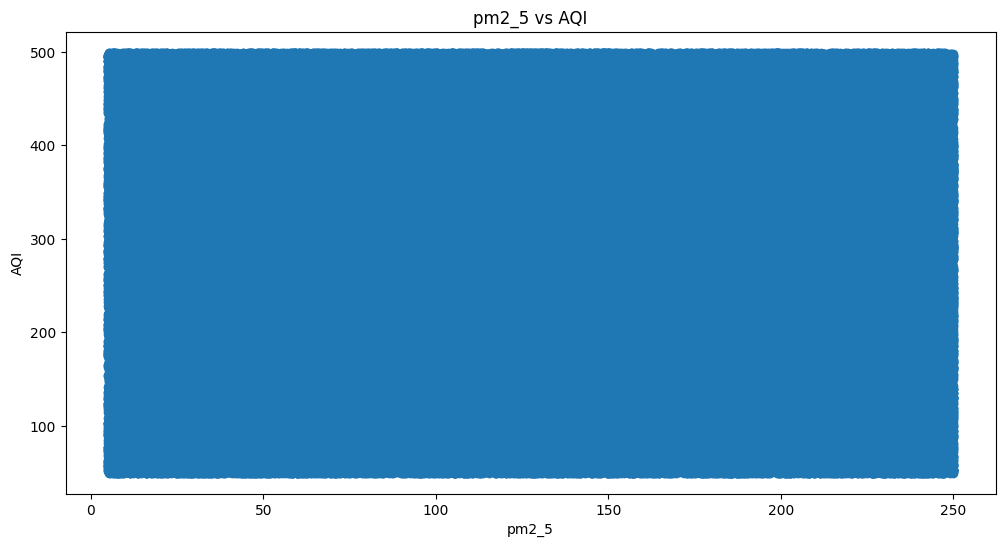

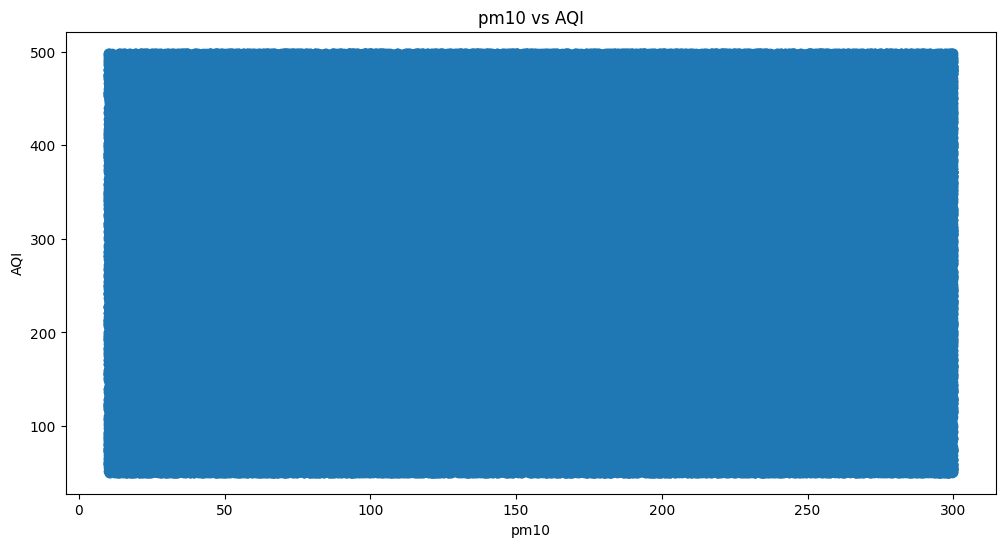

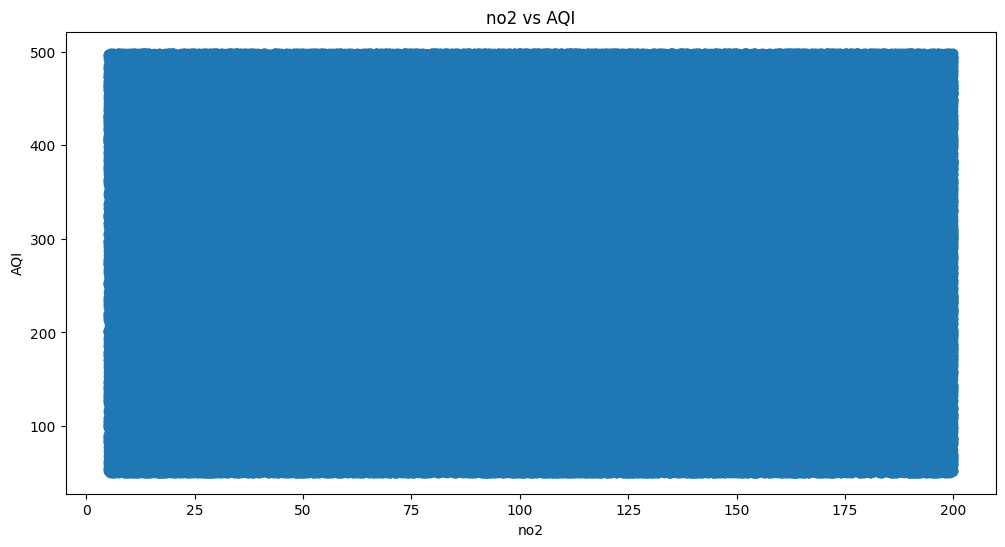

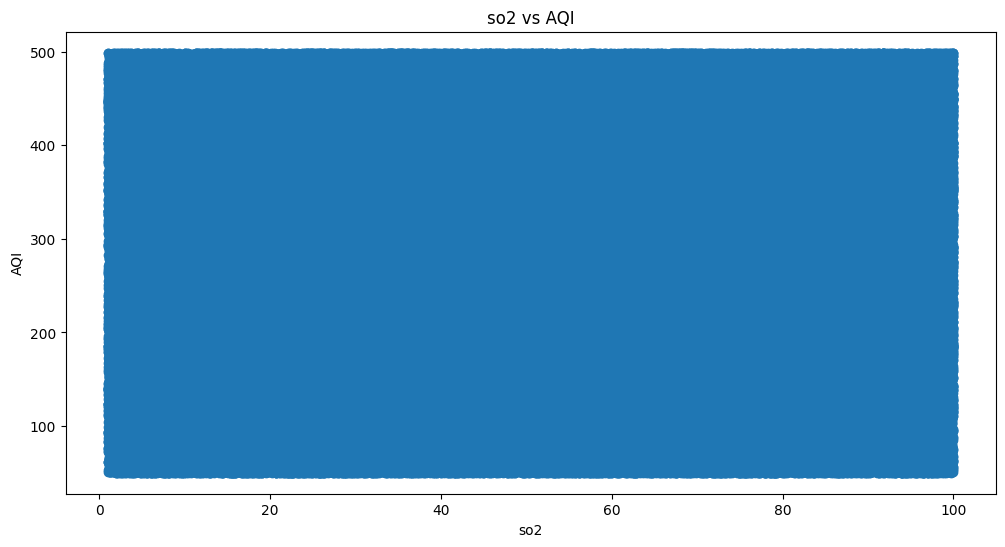

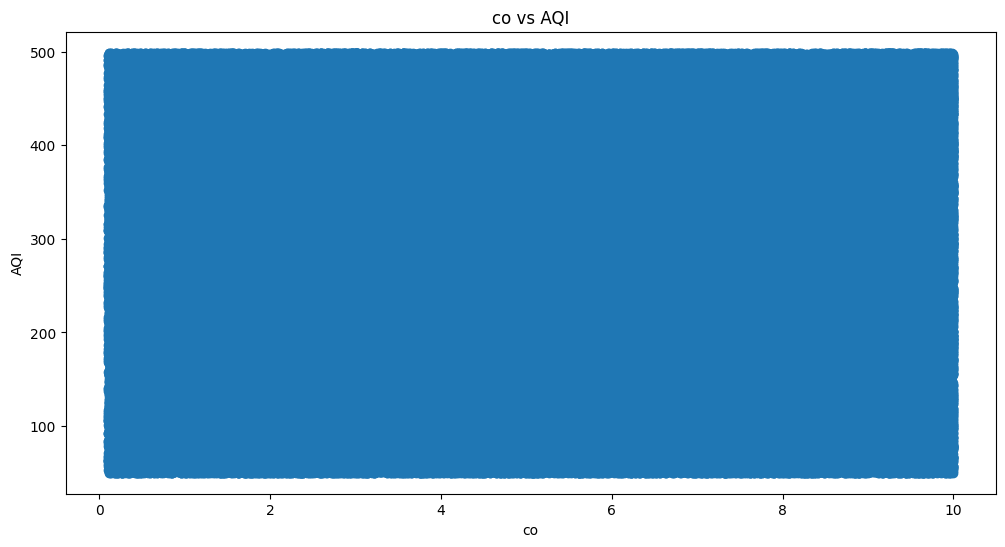

In [41]:
# 12. AQI vs Pollution Components
pollutants = ["pm2_5", "pm10", "no2", "so2", "co"]

for col in pollutants:
    plt.figure()
    plt.scatter(df[col], df["aqi"])
    plt.title(f"{col} vs AQI")
    plt.xlabel(col)
    plt.ylabel("AQI")
    plt.show()

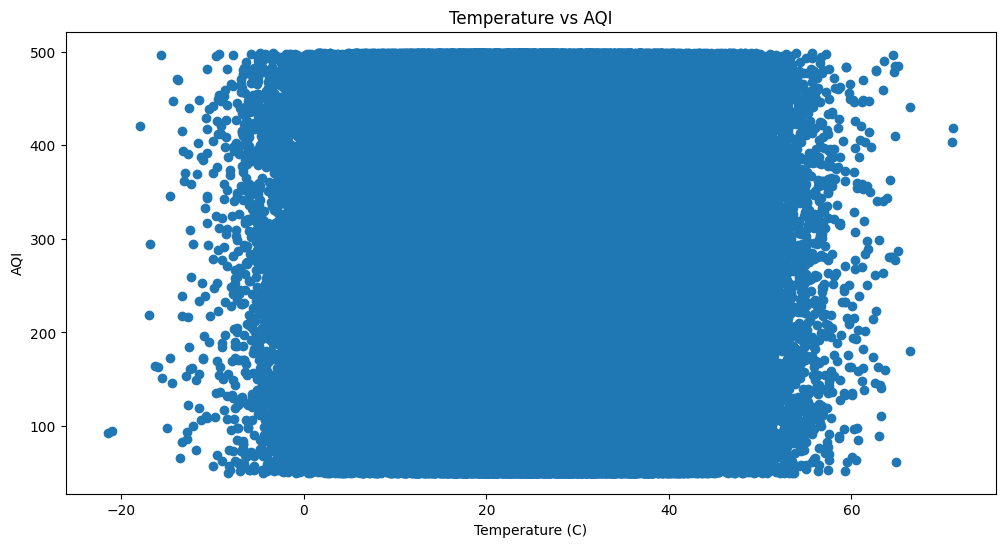

In [42]:
# 13. Temperature vs AQI
plt.scatter(df["temperature_c"], df["aqi"])
plt.title("Temperature vs AQI")
plt.xlabel("Temperature (C)")
plt.ylabel("AQI")
plt.show()

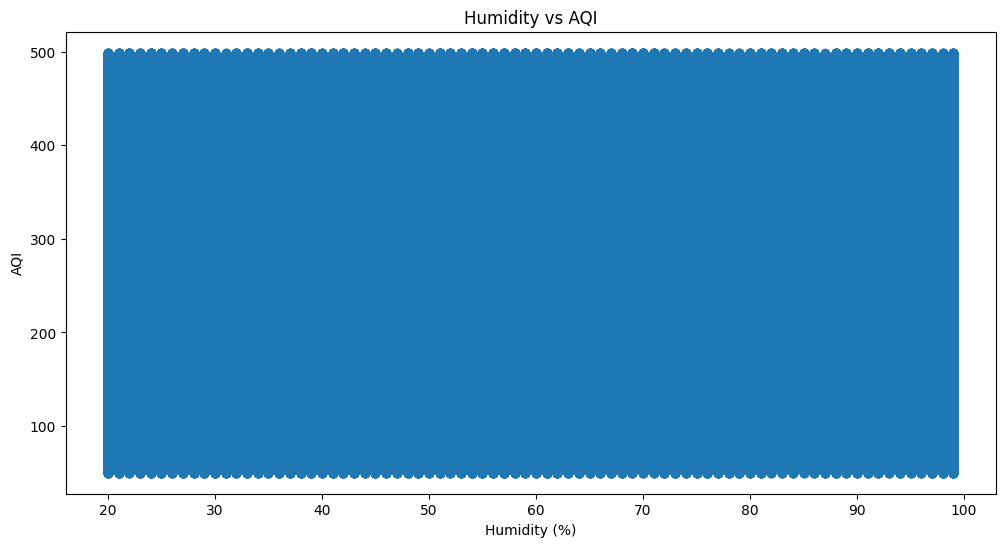

In [43]:
# 14. Humidity vs AQI
plt.scatter(df["humidity_percent"], df["aqi"])
plt.title("Humidity vs AQI")
plt.xlabel("Humidity (%)")
plt.ylabel("AQI")
plt.show()


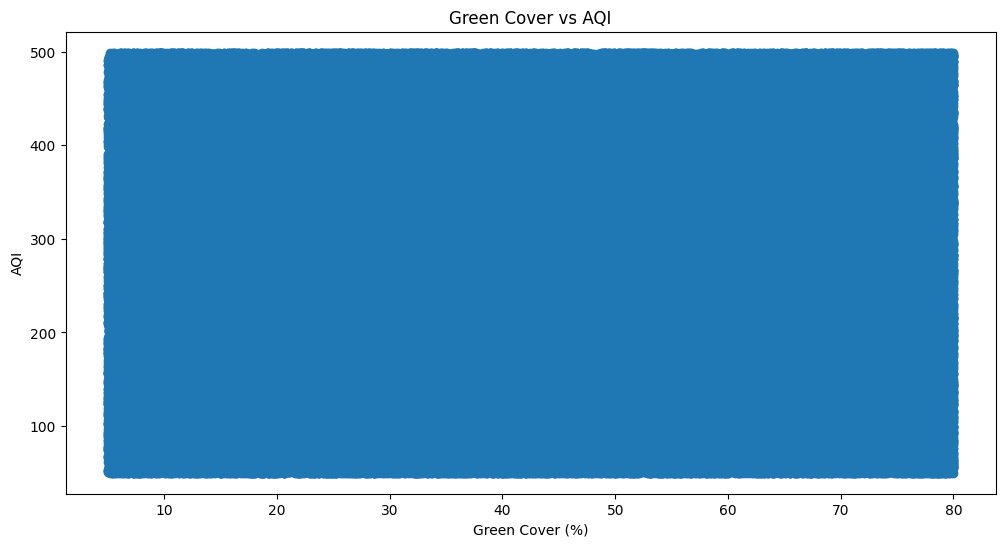

In [44]:
# 15. Green Cover Impact
plt.scatter(df["green_cover_percent"], df["aqi"])
plt.title("Green Cover vs AQI")
plt.xlabel("Green Cover (%)")
plt.ylabel("AQI")
plt.show()


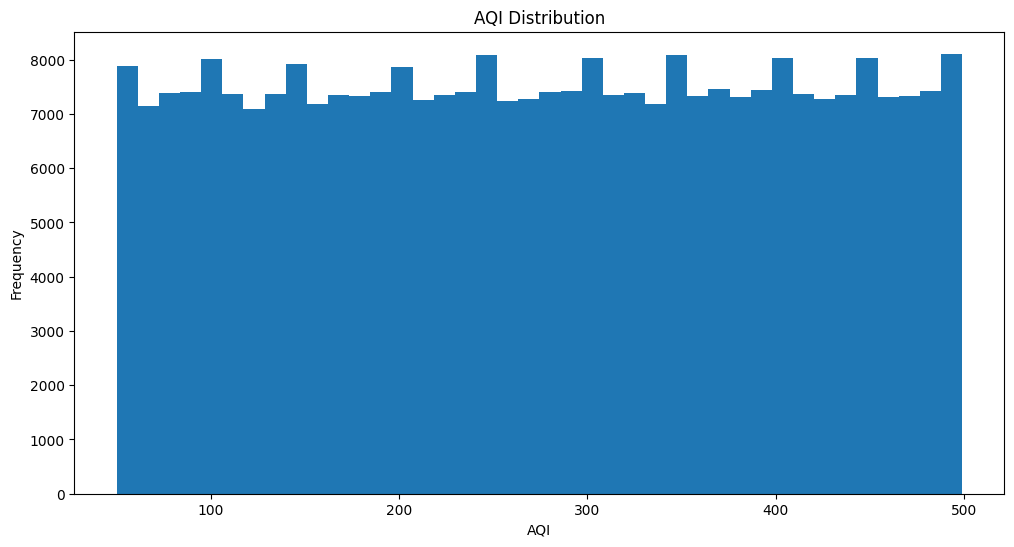

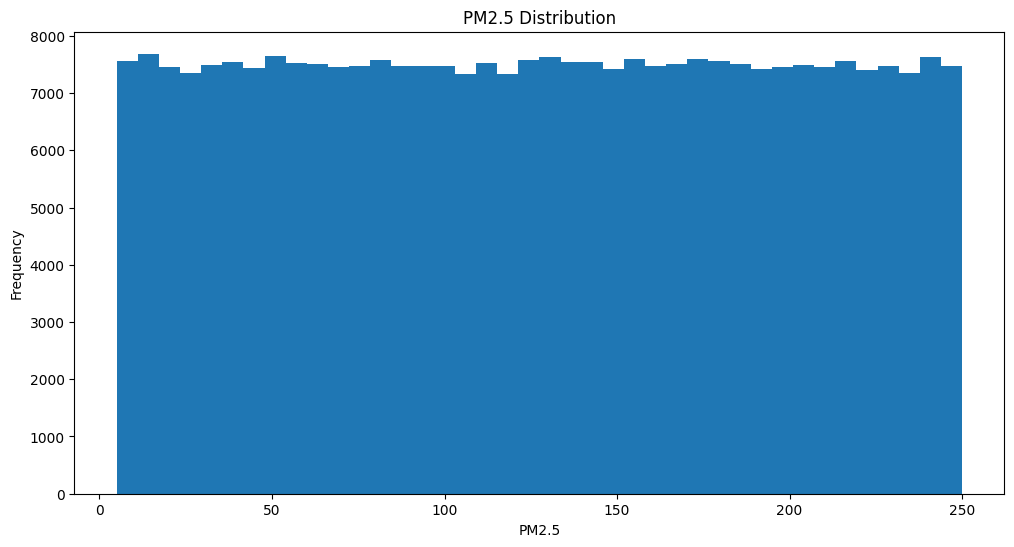

In [45]:
# 16. Distribution of AQI
plt.figure()
plt.hist(df["aqi"], bins=40)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

# 17. Distribution of PM2.5
plt.figure()
plt.hist(df["pm2_5"], bins=40)
plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()

In [46]:
# 18. High Pollution Events (AQI > 300)
high_pollution = df[df["aqi"] > 300]
print("\nHigh Pollution Events Count:", high_pollution.shape[0])



High Pollution Events Count: 133118


In [50]:
# 19. Low Pollution Events (AQI < 100)
low_pollution = df[df["aqi"] < 100]
print("\nLow Pollution Events Count:", low_pollution.shape[0])


Low Pollution Events Count: 33219


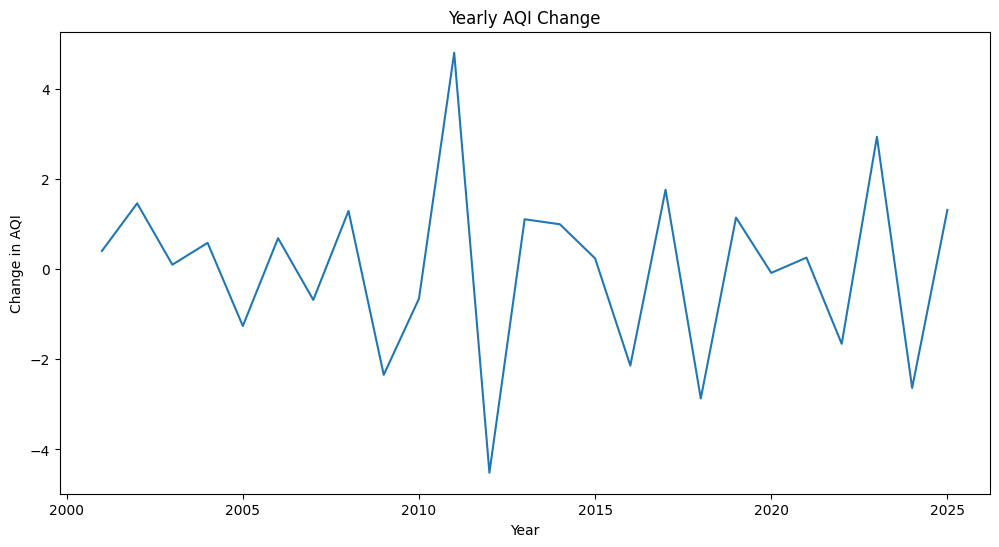

In [51]:
# 20. Yearly Improvement / Decline
yearly_change = df.groupby("year")["aqi"].mean().diff()

plt.figure()
plt.plot(yearly_change.index, yearly_change.values)
plt.title("Yearly AQI Change")
plt.xlabel("Year")
plt.ylabel("Change in AQI")
plt.show()

In [52]:
# 21. Top Countries Improving (Lower AQI Over Time)
first_year = df["year"].min()
last_year = df["year"].max()

start = df[df["year"] == first_year][["country", "aqi"]].rename(columns={"aqi": "start_aqi"})
end = df[df["year"] == last_year][["country", "aqi"]].rename(columns={"aqi": "end_aqi"})

improvement = pd.merge(start, end, on="country")
improvement["change"] = improvement["end_aqi"] - improvement["start_aqi"]

print("\nTop Improving Countries:\n", improvement.sort_values("change").head(10))
print("\nTop Declining Countries:\n", improvement.sort_values("change", ascending=False).head(10))


Top Improving Countries:
           country  start_aqi  end_aqi  change
6371229    Canada        499       50    -449
8991107     China        499       50    -449
3185746    Canada        499       50    -449
11422853   Canada        499       50    -449
6090107   Germany        499       50    -449
1464657    France        499       50    -449
1464981    France        499       50    -449
11571901    China        499       50    -449
6992150   Germany        499       50    -449
4829270     Japan        499       50    -449

Top Declining Countries:
          country  start_aqi  end_aqi  change
9339616   France         50      499     449
6796902   Canada         50      499     449
9722914   Brazil         50      499     449
9591158       UK         50      499     449
9591255       UK         50      499     449
12570095   China         50      499     449
12569352   China         50      499     449
12569339   China         50      499     449
11187294      UK         50      49

In [53]:
# 22. Region vs Pollutants Pivot Table
pivot = pd.pivot_table(
    df,
    values="aqi",
    index="region",
    columns="year",
    aggfunc="mean"
)

print("\nRegion-Year AQI Pivot:\n", pivot.head())


Region-Year AQI Pivot:
 year                 2000        2001        2002        2003        2004  \
region                                                                      
Asia           279.024587  275.118080  275.981545  279.251969  279.030750   
Europe         275.464395  273.550000  274.797762  274.606621  277.419244   
North America  269.755556  272.438163  276.055770  275.211538  273.613070   
Oceania        276.889284  276.505190  275.995680  273.401378  275.396384   
South America  269.669705  275.151067  277.316885  278.112350  277.953953   

year                 2005        2006        2007        2008        2009  \
region                                                                      
Asia           278.520172  276.647986  272.561753  272.456625  275.265000   
Europe         275.636325  275.699190  273.932903  281.213694  272.382340   
North America  268.035436  273.562212  278.356803  279.936973  275.615120   
Oceania        276.454663  277.461304  277.384779 